# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:** Дубовикова Софья Андреевна

**Факт о себе:** люблю котов🐱, фигурное катание⛸ и Ваню Дмитриенко🎤


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итоговая оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-19 17:26:51--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [           <=>      ] 201.24M  89.7MB/s    in 2.2s    

2025-10-19 17:26:54 (89.7 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [ ]:
df = pd.read_csv('yearpredictionmsd.zip', header=None) #загрузка данных, столбцы пронумерованы
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [ ]:
df.describe() #базовые статистики численных переменных

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

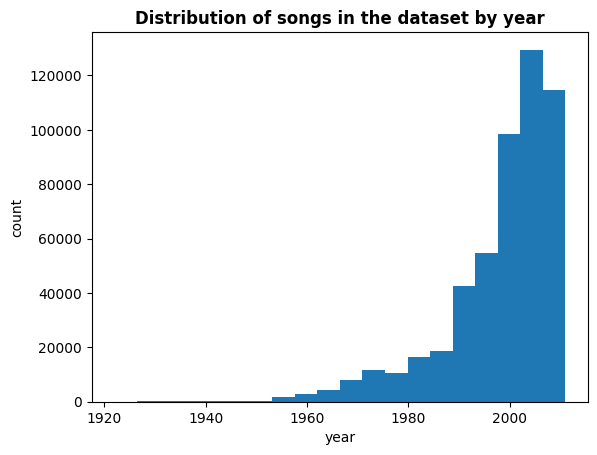

Range: 1922 - 2011
Unique values: 89


In [ ]:
plt.hist(df.iloc[:, 0], bins=20) #гистограмма для 0-ого столбца (20 колонок)
plt.title("Distribution of songs in the dataset by year", fontsize=12, weight="heavy")
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed) #генератор случайных чисел pytorch на cpu
    torch.cuda.manual_seed(seed) #генератор случайных чисел pytorch для текущего gpu
    torch.cuda.manual_seed_all(seed) #генератор случайных чисел pytorch для всех доступных gpu
    np.random.seed(seed) #генератор случайных чисел numpy
    random.seed(seed) #генератор случайных чисел библиотеки random

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge()
model.fit(X_train_scaled, y_train)
rmse_for_model = root_mean_squared_error(y_test, model.predict(X_test_scaled))
rmse_for_model

9.47363033268409

**Модель 1** - *Ridge-регрессия из sklearn* - показала ошибку на тесте, равную 9.4736. От этого показателя мы будем отталкиваться, пытаясь улучшить качество предсказания модели.

Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [ ]:
y_train_mean = np.mean(y_train)
y_pred = y_train_mean #константный прогноз
best_rmse_metric = np.sqrt(((y_test - y_pred) ** 2).mean()) #или root_mean_squared_error(y_test, y_pred)
best_rmse_metric

np.float64(10.845542969687791)

**Модель 2** - *константный прогноз* - показывает еще худшее качество по сравнению с Ridge-регрессией (RMSE=10.8455), поскольку является более примитивной: она не предусматривает вычисления градиентов и регуляризацию и сильно зависит от значений обучающей выборки.

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [ ]:
#масштабирование признаков
from sklearn.preprocessing import MinMaxScaler #заменим StandardScaler на другой

scaler = MinMaxScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [ ]:
#создание даталодеров
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val_sc, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
from torch import nn

class LinReg(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layer = nn.Linear(n_features, 1) #слой

    def forward(self, x):
        return self.layer(x)

In [ ]:
#обучение и валидация
from tqdm.notebook import tqdm

model = LinReg(n_features=90).to(device)

#rmse - метрика качества
#mse - функция потерь (loss)

mse_train = []
mse_val = []
rmse_train = []
rmse_val = []

for epoch in range(10):

    model.train()
    train_mse_sum = 0
    train_rmse_sum = 0

    for features, answers in tqdm(train_loader):
        features = features.to(device)
        answers = answers.to(device)

        answers_pred = model(features)

        loss = ((answers - answers_pred) ** 2).mean() #mse

        model.zero_grad()

        loss.backward()

        with torch.no_grad():
            for param in model.parameters():
                param -= 0.01 * param.grad

        train_mse_sum += loss.item()
        train_rmse_sum += torch.sqrt(loss).item()

    model.eval()
    val_mse_sum = 0
    val_rmse_sum = 0

    for features, answers in tqdm(val_loader):
        features = features.to(device)
        answers = answers.to(device)

        with torch.no_grad():
            answers_pred = model(features)

        loss = ((answers - answers_pred) ** 2).mean() #mse

        val_mse_sum += loss.item()
        val_rmse_sum += torch.sqrt(loss).item()

    train_mse_mean = train_mse_sum / len(train_loader)
    mse_train.append(train_mse_mean)

    train_rmse_mean = train_rmse_sum / len(train_loader)
    rmse_train.append(train_rmse_mean)

    val_mse_mean = val_mse_sum / len(val_loader)
    mse_val.append(val_mse_mean)

    val_rmse_mean = val_rmse_sum / len(val_loader)
    rmse_val.append(val_rmse_mean)

    print(f"Epoch: {epoch}, Train RMSE: {train_rmse_mean:.4f}, Validation RMSE: {val_rmse_mean:.4f}")


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 17.4942, Validation RMSE: 15.8008


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 8, Train RMSE: 13.2534, Validation RMSE: 13.2541


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 9, Train RMSE: 13.1358, Validation RMSE: 13.1513


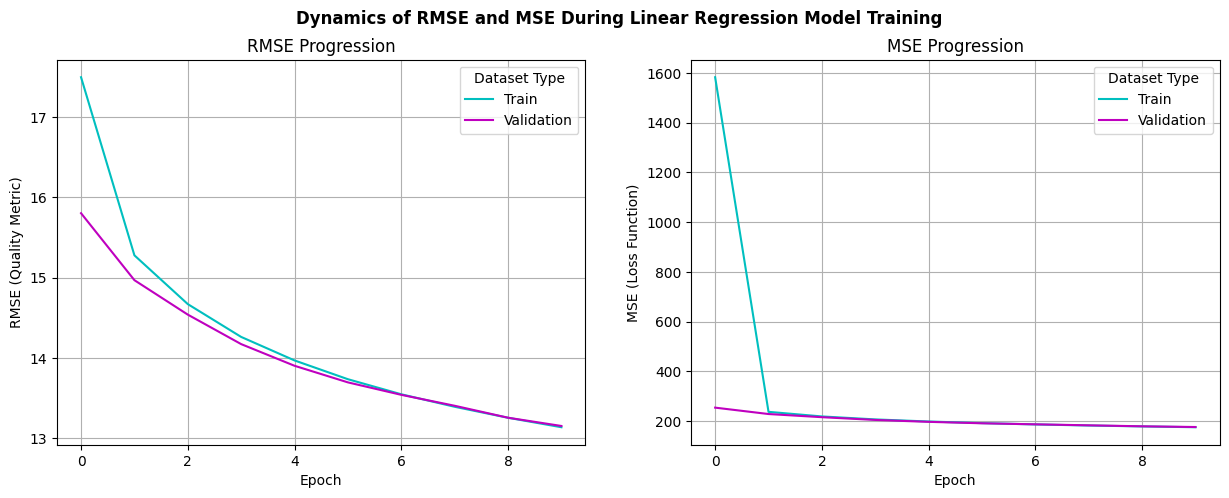

In [ ]:
#визуализация данных
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Dynamics of RMSE and MSE During Linear Regression Model Training", fontsize=12, weight="heavy")

ax1.set_title("RMSE Progression") #метрика
ax1.plot(rmse_train, c="c", label="Train")
ax1.plot(rmse_val, c="m", label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("RMSE (Quality Metric)")
ax1.legend(title="Dataset Type")
ax1.grid()

ax2.set_title("MSE Progression") #функция потерь
ax2.plot(mse_train, c="c", label="Train")
ax2.plot(mse_val, c="m", label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE (Loss Function)")
ax2.legend(title="Dataset Type")
ax2.grid()

plt.show()

In [ ]:
#оценка итогового качества модели
model.eval()
test_rmse_sum = 0

for features, answers in test_loader:
    features = features.to(device)
    answers = answers.to(device)

    with torch.no_grad():
        answers_pred = model(features)

        loss = ((answers_pred - answers) ** 2).mean()  #mse

        test_rmse_sum += torch.sqrt(loss).item()

test_rmse_mean = test_rmse_sum / len(test_loader)

print(f"Test RMSE: {test_rmse_mean:.4f}")

Test RMSE: 12.4745


**Модель 3** - *линейная регрессия pytorch с lr=0.01 и MinMaxScaler* - еще более далека от идеала и показывает качество еще меньшее (RMSE=12.4745), чем константный прогноз. В данном случае, вероятно, выбран не самый лучший scaler и lr, а также линейная регрессия может не улавливать нелинейные зависимости.

**Использованный источник:** https://stackoverflow.com/questions/44429199/how-to-load-a-list-of-numpy-arrays-to-pytorch-dataset-loader


## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """

    # your code here  ♪┏(・o･)┛♪

    raise NotImplementedError


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    # your code here   ฅ^•ﻌ•^ฅ

    raise NotImplementedError


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    # your code here  =^･ω･^=

    predicts = torch.ones(len(test_loader.dataset))
    return predicts


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    # your code here  ¯\_(ツ)_/¯

    raise NotImplementedError

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [ ]:
#масштабирование признаков
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#X_train_sc = scaler.fit_transform(X_train)
#X_val_sc = scaler.transform(X_val)
#X_test_sc = scaler.transform(X_test)

In [ ]:
#создание даталодеров
#from torch.utils.data import DataLoader, TensorDataset

#X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
#X_val_tensor = torch.tensor(X_val_sc, dtype=torch.float32)
#X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

y_train_classes, y_train_uniques = pd.factorize(y_train)
y_val_classes, y_val_uniques = pd.factorize(y_val)
y_test_classes, y_test_uniques = pd.factorize(y_test)

y_train_tensor_classes = torch.tensor(y_train_classes, dtype=torch.int64)
y_val_tensor_classes = torch.tensor(y_val_classes, dtype=torch.int64)
y_test_tensor_classes = torch.tensor(y_test_classes, dtype=torch.int64)

train_dataset_cl = TensorDataset(X_train_tensor, y_train_tensor_classes)
val_dataset_cl = TensorDataset(X_val_tensor, y_val_tensor_classes)
test_dataset_cl = TensorDataset(X_test_tensor, y_test_tensor_classes)

train_loader_cl = DataLoader(train_dataset_cl, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader_cl = DataLoader(val_dataset_cl, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader_cl = DataLoader(test_dataset_cl, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.layer2 = nn.Linear(128, n_classes) #слой 2

    def forward(self, x):
        x = F.relu(self.layer1(x))
        return self.layer2(x)

In [ ]:
model = NeuralNet(n_features=90, n_classes=89).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss()

In [ ]:
#обучение и валидация
def training_epoch(model, optimizer, criterion, train_loader, y_train_uniques):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """

    #loss - функция потерь (в данном случае - crossentropyloss)
    #rmse - метрика качества

    model.train()
    train_loss_sum = 0
    train_rmse_sum = 0

    y_train_uniques_tensor = torch.tensor(y_train_uniques, dtype=torch.float32).to(device)

    for features, classes in tqdm(train_loader):
        features = features.to(device)
        classes = classes.to(device)

        optimizer.zero_grad()

        logits = model(features)

        loss = criterion(logits, classes)

        loss.backward()

        optimizer.step()

        #вычисление rmse
        classes_pred = torch.argmax(logits, dim=-1) #перевод логитов в классы
        years_pred = y_train_uniques_tensor[classes_pred] #перевод классов в годы
        years_true = y_train_uniques_tensor[classes]
        rmse = torch.sqrt(((years_pred - years_true) ** 2).mean())

        train_loss_sum += loss.item()
        train_rmse_sum += rmse.item()

    train_loss_mean = train_loss_sum / len(train_loader)
    train_rmse_mean = train_rmse_sum / len(train_loader)

    return train_loss_mean, train_rmse_mean

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, y_val_uniques):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    model.eval()
    val_loss_sum = 0
    val_rmse_sum = 0

    y_val_uniques_tensor = torch.tensor(y_val_uniques, dtype=torch.float32).to(device)

    for features, classes in tqdm(val_loader):
        features = features.to(device)
        classes = classes.to(device)

        with torch.no_grad():
            logits = model(features)

            loss = criterion(logits, classes)

        #вычисление rmse
        classes_pred = torch.argmax(logits, dim=-1) #перевод логитов в классы
        years_pred = y_val_uniques_tensor[classes_pred] #перевод классов в годы
        years_true = y_val_uniques_tensor[classes]
        rmse = torch.sqrt(((years_pred - years_true) ** 2).mean())

        val_loss_sum += loss.item()
        val_rmse_sum += rmse.item()

    val_loss_mean = val_loss_sum / len(val_loader)
    val_rmse_mean = val_rmse_sum / len(val_loader)

    return val_loss_mean, val_rmse_mean

def train(model, optimizer, criterion, train_loader, val_loader, y_train_uniques, y_val_uniques, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_loss = []
    train_rmse = []
    val_loss = []
    val_rmse = []

    for epoch in range(epochs):
        train_loss_epoch, train_rmse_epoch = training_epoch(model, optimizer, criterion, train_loader, y_train_uniques)
        val_loss_epoch, val_rmse_epoch = validation_epoch(model, criterion, val_loader, y_val_uniques)

        train_loss.append(train_loss_epoch)
        train_rmse.append(train_rmse_epoch)

        val_loss.append(val_loss_epoch)
        val_rmse.append(val_rmse_epoch)

        print(f"Epoch: {epoch}, Train RMSE: {train_rmse_epoch:.4f}, Validation RMSE: {val_rmse_epoch:.4f}")

    return train_loss, train_rmse, val_loss, val_rmse

In [ ]:
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_cl, val_loader=val_loader_cl,
                                                   y_train_uniques=y_train_uniques, y_val_uniques=y_val_uniques, epochs=4)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 13.2062, Validation RMSE: 11.1740


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 13.7788, Validation RMSE: 11.8482


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 13.7385, Validation RMSE: 17.2916


In [ ]:
#оценка итогового качества модели
@torch.no_grad()
def predict(model, criterion, test_loader, y_test_uniques):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()
    test_rmse_sum = 0
    predicts = []

    y_test_uniques_tensor = torch.tensor(y_test_uniques, dtype=torch.float32).to(device)

    for features, classes in test_loader:
        features = features.to(device)
        classes = classes.to(device)

        with torch.no_grad():
            logits = model(features)

            loss = criterion(logits, classes)

        #вычисление rmse
        classes_pred = torch.argmax(logits, dim=-1) #перевод логитов в классы
        years_pred = y_test_uniques_tensor[classes_pred] #перевод классов в годы
        years_true = y_test_uniques_tensor[classes]
        rmse = torch.sqrt(((years_pred - years_true) ** 2).mean())

        test_rmse_sum += rmse.item()
        predicts.append(years_pred)

    test_rmse_mean = test_rmse_sum / len(test_loader)
    predicts = torch.cat(predicts, dim=0)

    print(f"Test RMSE: {test_rmse_mean:.4f}")

    return predicts, test_rmse_mean

In [ ]:
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_cl, y_test_uniques=y_test_uniques)

Test RMSE: 12.8309


**Модель 4** - *нейронная сеть, обученная на классификацию* - показала качество меньшее (RMSE=12.8309), чем предыдущие модели, что говорит о том, что использовать классификацию все же неэффективно.

**Использованный источник:**
https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** бейзлайн побить не удалось. Кроме того, модель ведет себя нестабильно на валидации, что говорит о том, что она плохо обощает новые данные.
На мой взгляд, использование классификации для этой задачи не является оптимальным выбором, т.к. год выпуска — это числовая переменная, а не категориальная, и дискретизация целевой переменной в классы приводит к потере информации и усложняет задачу обучения.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
#масштабирование признаков
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#X_train_sc = scaler.fit_transform(X_train)
#X_val_sc = scaler.transform(X_val)
#X_test_sc = scaler.transform(X_test)

In [ ]:
#создание даталодеров
#from torch.utils.data import DataLoader, TensorDataset

#X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
#y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) #аналогично reshape(-1, 1)

#X_val_tensor = torch.tensor(X_val_sc, dtype=torch.float32)
#y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

#X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
#y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

#train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
#test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
#val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
#test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
#import torch.nn.functional as F

#class NeuralNet(nn.Module):
    #def __init__(self, n_features, n_classes):
        #super().__init__()
        #self.layer1 = nn.Linear(n_features, 128) #слой 1
        #self.layer2 = nn.Linear(128, n_classes) #слой 2

    #def forward(self, x):
        #x = F.relu(self.layer1(x))
        #return self.layer2(x)

In [ ]:
model = NeuralNet(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """

    #loss - функция потерь (в данном случае - mse)
    #rmse - метрика качества

    model.train()
    train_loss_sum = 0
    train_rmse_sum = 0

    for features, years in tqdm(train_loader):
        features = features.to(device)
        years = years.to(device)

        optimizer.zero_grad()

        years_pred = model(features)

        loss = criterion(years_pred, years)

        loss.backward()

        optimizer.step()

        rmse = torch.sqrt(((years - years_pred) ** 2).mean())

        train_loss_sum += loss.item()
        train_rmse_sum += rmse.item()

    train_loss_mean = train_loss_sum / len(train_loader)
    train_rmse_mean = train_rmse_sum / len(train_loader)

    return train_loss_mean, train_rmse_mean

@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    model.eval()
    val_loss_sum = 0
    val_rmse_sum = 0

    for features, years in tqdm(val_loader):
        features = features.to(device)
        years = years.to(device)

        with torch.no_grad():
            years_pred = model(features)

            loss = criterion(years_pred, years)

            rmse = torch.sqrt(((years - years_pred) ** 2).mean())

        val_loss_sum += loss.item()
        val_rmse_sum += rmse.item()

    val_loss_mean = val_loss_sum / len(val_loader)
    val_rmse_mean = val_rmse_sum / len(val_loader)

    return val_loss_mean, val_rmse_mean

def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_loss = []
    train_rmse = []
    val_loss = []
    val_rmse = []

    for epoch in range(epochs):
        train_loss_epoch, train_rmse_epoch = training_epoch(model, optimizer, criterion, train_loader)
        val_loss_epoch, val_rmse_epoch = validation_epoch(model, criterion, val_loader)

        train_loss.append(train_loss_epoch)
        train_rmse.append(train_rmse_epoch)

        val_loss.append(val_loss_epoch)
        val_rmse.append(val_rmse_epoch)

        print(f"Epoch: {epoch}, Train RMSE: {train_rmse_epoch:.4f}, Validation RMSE: {val_rmse_epoch:.4f}")

    return train_loss, train_rmse, val_loss, val_rmse

In [ ]:
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader, val_loader=val_loader, epochs=4)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 301.6419, Validation RMSE: 10.8829


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 10.8327, Validation RMSE: 10.8756


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 10.8310, Validation RMSE: 10.8756


In [ ]:
model = NeuralNet(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

criterion = nn.MSELoss()

train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader, val_loader=val_loader, epochs=4)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 904.7606, Validation RMSE: 430.9460


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 491.6899, Validation RMSE: 350.3164


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 389.1384, Validation RMSE: 292.4258


In [ ]:
model = NeuralNet(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=5e-4)

criterion = nn.MSELoss()

train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader, val_loader=val_loader, epochs=4)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 449.9815, Validation RMSE: 63.1854


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 18.2200, Validation RMSE: 9.8139


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 14.7192, Validation RMSE: 10.5027


In [ ]:
#оценка итогового качества модели
@torch.no_grad()
def predict(model, criterion, test_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()
    test_rmse_sum = 0
    predicts = []

    for features, years in tqdm(test_loader):
        features = features.to(device)
        years = years.to(device)

        with torch.no_grad():
            years_pred = model(features)

            loss = criterion(years_pred, years)

            rmse = torch.sqrt(((years - years_pred) ** 2).mean())

        test_rmse_sum += rmse.item()
        predicts.append(years_pred)

    test_rmse_mean = test_rmse_sum / len(test_loader)
    predicts = torch.cat(predicts, dim=0)

    print(f"Test RMSE: {test_rmse_mean:.4f}")

    return predicts, test_rmse_mean

In [ ]:
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 9.1430


**Модель 5** - *нейронная сеть, обученная как регрессия* - показала наилучшее качество (RMSE=9.1430), даже превосходящее исходный бейзлайн, но она ведет себя очень нестабильно, особенно при больших lr.

**Использованный источник:** https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** с исходным lr=1e-3 обучение плюс-минус стабилизировалось и сильно резких скачков уже не наблюдалось, однако после уменьшения lr модель стала очень нестабильной. Да, в плане качества на тесте стало лучше от замены классификации на регрессию, т.к. теперь модель предсказывает числовое значение года, а не вероятности классов, что позволяет ей лучше улавливать численные зависимости.
Если обратиться к распределению значений целевой переменной, то оно очень неравномерное, поэтому классификация, вероятно, предсказывала наиболее популярные (частые) годы выпуска и не улавливала зависимостей.
Однако нестабильность модели говорит о необходиомсти дальнейших преобразований.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    minimum = np.min(y_train)
    maximum = np.max(y_train)

    sample_norm = (sample - minimum) / (maximum - minimum)

    return sample_norm

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    minimum = np.min(y_train)
    maximum = np.max(y_train)

    sample_denorm = sample*(maximum - minimum) + minimum

    return sample_denorm

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [ ]:
#масштабирование признаков
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#X_train_sc = scaler.fit_transform(X_train)
#X_val_sc = scaler.transform(X_val)
#X_test_sc = scaler.transform(X_test)

In [ ]:
#создание даталодеров
#from torch.utils.data import DataLoader, TensorDataset

#X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
#X_val_tensor = torch.tensor(X_val_sc, dtype=torch.float32)
#X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

y_train_norm = normalize(y_train)
y_val_norm = normalize(y_val)
y_test_norm = normalize(y_test)

y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32).reshape(-1, 1)
y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32).reshape(-1, 1)
y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32).reshape(-1, 1)

train_dataset_norm = TensorDataset(X_train_tensor, y_train_tensor_norm)
val_dataset_norm = TensorDataset(X_val_tensor, y_val_tensor_norm)
test_dataset_norm = TensorDataset(X_test_tensor, y_test_tensor_norm)

train_loader_norm = DataLoader(train_dataset_norm, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader_norm = DataLoader(val_dataset_norm, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader_norm = DataLoader(test_dataset_norm, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
#import torch.nn.functional as F

class NeuralNet_SigmAct(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.layer2 = nn.Linear(128, n_classes) #слой 2

    def forward(self, x):
        x = F.relu(self.layer1(x))
        return F.sigmoid(self.layer2(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_norm, val_loader=val_loader_norm, epochs=4)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1566, Validation RMSE: 0.1228


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 0.1217, Validation RMSE: 0.1221


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 0.1217, Validation RMSE: 0.1221


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_norm)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.1095


**Модель 6** - *нейронная сеть, обученная как регрессия на нормированной целевой переменной с сигмоидной активацией в конце*, показала RMSE=0.1095, но он не сопоставим с предыдущими RMSE, так как целевая переменная была взята в другом масштабе. Использовав min-max нормализацию, мы привели целевую переменную к масштабу от 0 до 1, а не от 1922 до 2011 года, поэтому полученное значение необходимо домножить на 2011-1922=89. Получаем RMSE=0.1095*89=9.7455, что говорит о немного худшем качестве по сравнению с предыдущей моделью без нормализации таргета.

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
#масштабирование признаков
#from sklearn.preprocessing import StandardScaler

scaler_st = StandardScaler()

X_train_sc_st = scaler_st.fit_transform(X_train)
X_val_sc_st = scaler_st.transform(X_val)
X_test_sc_st = scaler_st.transform(X_test)

In [ ]:
#создание даталодеров
#from torch.utils.data import DataLoader, TensorDataset

X_train_tensor_st = torch.tensor(X_train_sc_st, dtype=torch.float32)
X_val_tensor_st = torch.tensor(X_val_sc_st, dtype=torch.float32)
X_test_tensor_st = torch.tensor(X_test_sc_st, dtype=torch.float32)

#y_train_norm = normalize(y_train)
#y_val_norm = normalize(y_val)
#y_test_norm = normalize(y_test)

#y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32).reshape(-1, 1)
#y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32).reshape(-1, 1)
#y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32).reshape(-1, 1)

train_dataset_final = TensorDataset(X_train_tensor_st, y_train_tensor_norm)
val_dataset_final= TensorDataset(X_val_tensor_st, y_val_tensor_norm)
test_dataset_final = TensorDataset(X_test_tensor_st, y_test_tensor_norm)

train_loader_final = DataLoader(train_dataset_final, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader_final = DataLoader(val_dataset_final, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader_final = DataLoader(test_dataset_final, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
#import torch.nn.functional as F

#class NeuralNet_SigmAct(nn.Module):
    #def __init__(self, n_features, n_classes):
        #super().__init__()
        #self.layer1 = nn.Linear(n_features, 128) #слой 1
        #self.layer2 = nn.Linear(128, n_classes) #слой 2

    #def forward(self, x):
        #x = F.relu(self.layer1(x))
        #return F.sigmoid(self.layer2(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=10)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1997, Validation RMSE: 0.1417


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 8, Train RMSE: 0.1170, Validation RMSE: 0.1172


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 9, Train RMSE: 0.1163, Validation RMSE: 0.1165


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.1056


**Модель 7** - *нейронная сеть с нормализацией и признаков, и целевой переменной* - показала RMSE=0.1056, что для приведения в исходный масштаб необходимо тоже домножить на 89. Получаем RMSE=9.3984, что уже сопоставимо с бейзлайном и даже немного меньше него.

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [ ]:
#масштабирование признаков
#from sklearn.preprocessing import StandardScaler

#scaler_st = StandardScaler()

#X_train_sc_st = scaler_st.fit_transform(X_train)
#X_val_sc_st = scaler_st.transform(X_val)
#X_test_sc_st = scaler_st.transform(X_test)

In [ ]:
#создание даталодеров
#from torch.utils.data import DataLoader, TensorDataset

#X_train_tensor_st = torch.tensor(X_train_sc_st, dtype=torch.float32)
#X_val_tensor_st = torch.tensor(X_val_sc_st, dtype=torch.float32)
#X_test_tensor_st = torch.tensor(X_test_sc_st, dtype=torch.float32)

#y_train_norm = normalize(y_train)
#y_val_norm = normalize(y_val)
#y_test_norm = normalize(y_test)

#y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32).reshape(-1, 1)
#y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32).reshape(-1, 1)
#y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32).reshape(-1, 1)

#train_dataset_final = TensorDataset(X_train_tensor_st, y_train_tensor_norm)
#val_dataset_final= TensorDataset(X_val_tensor_st, y_val_tensor_norm)
#test_dataset_final = TensorDataset(X_test_tensor_st, y_test_tensor_norm)

#train_loader_final = DataLoader(train_dataset_final, batch_size=64, shuffle=True, worker_init_fn=seed_worker, generator=g)
#val_loader_final = DataLoader(val_dataset_final, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)
#test_loader_final = DataLoader(test_dataset_final, batch_size=64, shuffle=False, worker_init_fn=seed_worker, generator=g)

In [ ]:
#архитектура модели
#import torch.nn.functional as F

#class NeuralNet_SigmAct(nn.Module):
    #def __init__(self, n_features, n_classes):
        #super().__init__()
        #self.layer1 = nn.Linear(n_features, 128) #слой 1
        #self.layer2 = nn.Linear(128, n_classes) #слой 2

    #def forward(self, x):
        #x = F.relu(self.layer1(x))
        #return F.sigmoid(self.layer2(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=10)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1295, Validation RMSE: 0.1176


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 8, Train RMSE: 0.1052, Validation RMSE: 0.1054


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 9, Train RMSE: 0.1047, Validation RMSE: 0.1050


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0950


**Модель 8** - *нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором SGD c параметром momentum=0.9* - показала RMSE=0.095, что для приведения в исходный масштаб снова необходимо домножить на 89. Получаем RMSE=8.455, что говорит о том, что модель лучше бейзлайна по качеству.


In [ ]:
model = NeuralNet_SigmAct(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=10)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1036, Validation RMSE: 0.1002


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 8, Train RMSE: 0.0956, Validation RMSE: 0.0984


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 9, Train RMSE: 0.0953, Validation RMSE: 0.0984


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0896


**Модель 9** - *нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam* - показала RMSE=0.0896, что для приведения в исходный масштаб опять же необходимо домножить на 89. Получаем RMSE=7.9744, что говорит не только о большем качестве модели по сравнению с бейзлайном, но и по сравнению с SGD с параметром momentum.

***Adam оказался эффективнее, чем SGD с параметром momentum, т.к. показал меньшее RMSE на тесте. Оба оптимизатора сгладили валидацию, что говорит о том, что модель научилась обощать данные и применять их к новым выборкам. Оптимизатор Adam адаптирует скорость обучения для каждого параметра модели индивидуально, подстраивается под масштабы каждого признака, а также включает в себя momentum, который просто ускоряет градиентный спуск.***

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [ ]:
#архитектура модели
#import torch.nn.functional as F

class NeuralNet_SigmAct_Wide(nn.Module): #более широкая нейросеть
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 256) #слой 1
        self.layer2 = nn.Linear(256, n_classes) #слой 2

    def forward(self, x):
        x = F.relu(self.layer1(x))
        return F.sigmoid(self.layer2(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct_Wide(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=20)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1023, Validation RMSE: 0.1001


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 18, Train RMSE: 0.0919, Validation RMSE: 0.0981


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 19, Train RMSE: 0.0917, Validation RMSE: 0.0984


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0916


**Модель 10** - *более широкая нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam* - показала RMSE=0.0916. Домножаем на 89 и получаем RMSE=8.1524, что говорит о немного худшем качестве модели, по сравнению с предыдущей.

In [ ]:
#архитектура модели
#import torch.nn.functional as F

class NeuralNet_SigmAct_Deep(nn.Module): #более глубокая нейросеть
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.layer2 = nn.Linear(128, 128) #слой 2
        self.layer3 = nn.Linear(128, n_classes) #слой 3

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return F.sigmoid(self.layer3(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct_Deep(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=20)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1017, Validation RMSE: 0.0994


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 18, Train RMSE: 0.0861, Validation RMSE: 0.0991


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 19, Train RMSE: 0.0857, Validation RMSE: 0.0997


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0927


**Модель 11** - *более глубокая нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam* - показала RMSE=0.0927. Домножаем на 89 и получаем RMSE=8.2503, что хуже предыдущей модели.

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ в данном случае увеличение числа парметров привело к тому, что модели начали переобучаться, хоть это пока и не сильно заметно. В обоих случаях на тренировочных данных ошибка снижается, но на валидации она ведет себя нестабильно и после 20 эпох RMSE становится даже большим, чем было изначально.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [ ]:
#архитектура модели
#import torch.nn.functional as F

class NeuralNet_SigmAct_Deep_Reg1(nn.Module): #более глубокая нейросеть
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.dropout1 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(128, 128) #слой 2
        self.dropout2 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(128, n_classes) #слой 3

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        return F.sigmoid(self.layer3(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct_Deep_Reg1(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=20)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1035, Validation RMSE: 0.0999


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 18, Train RMSE: 0.0944, Validation RMSE: 0.0961


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 19, Train RMSE: 0.0944, Validation RMSE: 0.0971


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0895


**Модель 12** - *более глубокая нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam и дропаут-слоями* - показывает RMSE=0.0895*89=7.9655.

In [ ]:
#архитектура модели
#import torch.nn.functional as F

class NeuralNet_SigmAct_Deep_Reg2(nn.Module): #более глубокая нейросеть
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 128) #слой 2
        self.batchnorm2 = nn.BatchNorm1d(128)
        self.layer3 = nn.Linear(128, n_classes) #слой 3

    def forward(self, x):
        x = F.relu(self.batchnorm1(self.layer1(x)))
        x = F.relu(self.batchnorm2(self.layer2(x)))
        return F.sigmoid(self.layer3(x)) #добавление сигмоиды

In [ ]:
model = NeuralNet_SigmAct_Deep_Reg2(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [ ]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=20)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1023, Validation RMSE: 0.0991


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 18, Train RMSE: 0.0906, Validation RMSE: 0.0968


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 19, Train RMSE: 0.0905, Validation RMSE: 0.0968


In [ ]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0892


**Модель 13** - *более глубокая нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam и batch-нормализацией* - показывает RMSE=0.0892*89=7.9388, что ниже, чем у модели с дропаутом, а значит говорит о большем качестве.


**Использованный источник:** https://habr.com/ru/companies/mvideo/articles/782360/

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ как после добавления дропаута, так и после добавления батчнорма после 20 эпох RMSE на валидации становится значительно меньше исходного (после 1-ой эпохи), что говорит о том, что эти методы помогают снизить переобучение модели и улучшить ее качество и способность обобщать данные и находить зависимости. Однако тот факт, что после батчнорма RMSE на тестовых данных оказался ниже, говорит о том, что для наших данных он справляется лучше.

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [ ]:
lr_list = [1e-3, 1e-4, 5e-3, 5e-4]
train_rmse_list = []
val_rmse_list = []

for i in range(len(lr_list)):
    model = NeuralNet_SigmAct_Deep_Reg2(n_features=90, n_classes=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_list[i])
    criterion = nn.MSELoss()
    print(f'Learning Rate = {lr_list[i]}')
    train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=4)
    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)
    print(' ')


Learning Rate = 0.001


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1026, Validation RMSE: 0.0996


  0%|          | 0/4530 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 0.0972, Validation RMSE: 0.0975


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 0.0963, Validation RMSE: 0.0973
 


In [ ]:
train_rmse_array = np.array(train_rmse_list)
val_rmse_array = np.array(val_rmse_list)

train_rmse_mean = np.mean(train_rmse_array, axis=1)
val_rmse_mean = np.mean(val_rmse_array, axis=1)

print(f'lr={lr_list[np.argmin(val_rmse_mean)]} RMSE={np.min(val_rmse_mean)}')

lr=0.0005 RMSE=0.09801375188969619


In [ ]:
wd_list = [0, 1e-6, 1e-5, 1e-4, 1e-3]
train_rmse_list_new = []
val_rmse_list_new = []

for i in range(len(wd_list)):
    model = NeuralNet_SigmAct_Deep_Reg2(n_features=90, n_classes=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_list[np.argmin(val_rmse_mean)], weight_decay=wd_list[i])
    criterion = nn.MSELoss()
    print(f'Weight Decay = {wd_list[i]}')
    train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=4)
    train_rmse_list_new.append(train_rmse)
    val_rmse_list_new.append(val_rmse)
    print(' ')

Weight Decay = 0


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1040, Validation RMSE: 0.0999


  0%|          | 0/4530 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 2, Train RMSE: 0.1012, Validation RMSE: 0.1010


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 0.1011, Validation RMSE: 0.1010
 


In [ ]:
train_rmse_array_new = np.array(train_rmse_list_new)
val_rmse_array_new = np.array(val_rmse_list_new)

train_rmse_mean_new = np.mean(train_rmse_array_new, axis=1)
val_rmse_mean_new = np.mean(val_rmse_array_new, axis=1)

print(f'weight_decay={wd_list[np.argmin(val_rmse_mean_new)]} RMSE={np.min(val_rmse_mean_new)}')

weight_decay=0 RMSE=0.09831948800148158


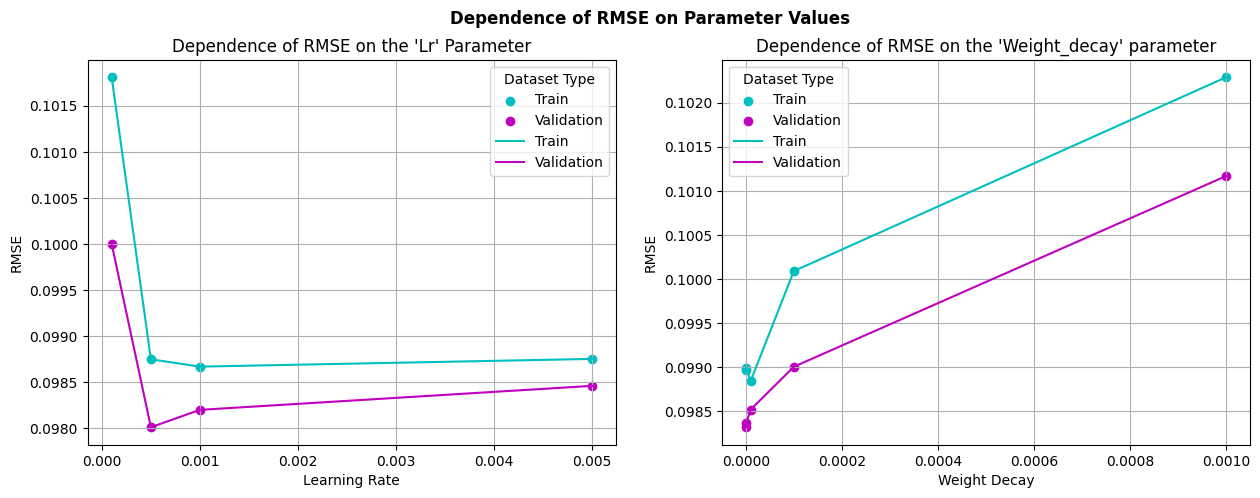

In [ ]:
#визуализация данных
sort_lr = np.argsort(lr_list)
lr_list_sorted = np.array(lr_list)[sort_lr]
train_rmse_mean_sorted = train_rmse_mean[sort_lr]
val_rmse_mean_sorted = val_rmse_mean[sort_lr]

sort_wd = np.argsort(wd_list)
wd_list_sorted = np.array(wd_list)[sort_wd]
train_rmse_mean_new_sorted = train_rmse_mean_new[sort_wd]
val_rmse_mean_new_sorted = val_rmse_mean_new[sort_wd]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Dependence of RMSE on Parameter Values", fontsize=12, weight="heavy")

ax1.set_title("Dependence of RMSE on the 'Lr' Parameter")
ax1.scatter(lr_list_sorted, train_rmse_mean_sorted, c="c", label="Train")
ax1.scatter(lr_list_sorted, val_rmse_mean_sorted, c="m", label="Validation")
ax1.plot(lr_list_sorted, train_rmse_mean_sorted, c="c", label="Train")
ax1.plot(lr_list_sorted, val_rmse_mean_sorted, c="m", label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("RMSE")
ax1.legend(title="Dataset Type")
ax1.grid()

ax2.set_title("Dependence of RMSE on the 'Weight_decay' parameter")
ax2.scatter(wd_list_sorted, train_rmse_mean_new_sorted, c="c", label="Train")
ax2.scatter(wd_list_sorted, val_rmse_mean_new_sorted, c="m", label="Validation")
ax2.plot(wd_list_sorted, train_rmse_mean_new_sorted, c="c", label="Train")
ax2.plot(wd_list_sorted, val_rmse_mean_new_sorted, c="m", label="Validation")
ax2.set_xlabel("Weight Decay")
ax2.set_ylabel("RMSE")
ax2.legend(title="Dataset Type")
ax2.grid()

plt.show()

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ от выбора гиперпараметров действительно очень сильно зависит качество модели. Оптимальными получились lr=0.0005 и weight_decay=0. На первом графике видно, что, если брать очень маленькую длину шага, то обучение будет медленным и мы можем не дойти до точки минимума, а если взять слишком большую длину шага - то градиент может не сойтись. На втором графике видно, что сначала регуляризация помогает предотвратить переобучение, но слишком сильная регуляризация может привести к недообучению. Анализируемая модель уже стабильна, поэтому не нуждается в регуляризации.

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [90]:
#архитектура модели
#import torch.nn.functional as F

#попробуем заменить ReLU на LeakyReLU

class NeuralNet_Last(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128) #слой 1
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 128) #слой 2
        self.batchnorm2 = nn.BatchNorm1d(128)
        self.layer3 = nn.Linear(128, n_classes) #слой 3

    def forward(self, x):
        x = F.leaky_relu(self.batchnorm1(self.layer1(x)))
        x = F.leaky_relu(self.batchnorm2(self.layer2(x)))
        return F.sigmoid(self.layer3(x)) #добавление сигмоиды

In [91]:
model = NeuralNet_Last(n_features=90, n_classes=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0)

criterion = nn.MSELoss()

In [92]:
#обучение и валидация
train_loss, train_rmse, val_loss, val_rmse = train(model=model, optimizer=optimizer, criterion=criterion,
                                                   train_loader=train_loader_final, val_loader=val_loader_final, epochs=5)

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 0, Train RMSE: 0.1033, Validation RMSE: 0.0995


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 3, Train RMSE: 0.0963, Validation RMSE: 0.0977


  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

Epoch: 4, Train RMSE: 0.0956, Validation RMSE: 0.0969


In [93]:
#оценка итогового качества модели
predicts, test_rmse = predict(model=model, criterion=criterion,
                              test_loader=test_loader_final)

  0%|          | 0/2014 [00:00<?, ?it/s]

Test RMSE: 0.0883


**Модель 14** - *более глубокая нейронная сеть с нормализацией и признаков, и целевой переменной с оптимизатором Adam, batch-нормализацией, функцией активации LeakyReLU и подобранными значениями lr=0.0005 и weight_decay=0* показала RMSE на тестовых данных, равное 0.0883*89=7.8587, то есть при редсказании года выпуска песни модель ошибается в среднем на 7-8 лет.

**Использованный источник:** https://habr.com/ru/articles/727506/

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ я попробовала заменить функцию активации ReLU на более гладкую LeakyReLU, т.к. в используемом датасете много отрицательных значений, которые ReLU обнуляла. LeakyReLU не обнуляет отрицательные значения, поэтому они тоже вносят вклад в выходную функцию. В результате было получено наилучшее из всех моделей качество.

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

![Сентябрь](https://drive.google.com/uc?export=view&id=1vqOKUXkO3ZP-MBpFTQE9gz7_nvWiN6oL)

*Сентябрь, полный любви 💗*

